# MS COCO Dataset(Colab 무료버전에서 실행,CPU사용)

In [ ]:
# ! pip install "git+https://github.com/philferriere/cocoapi.git#egg=pycocotools&subdirectory=PythonAPI"

In [ ]:
#  window에서 pycocotools 설치하기
#  https://eatchu.tistory.com/entry/window%EC%97%90%EC%84%9C-pycocotools-%EC%84%A4%EC%B9%98%ED%95%98%EA%B8%B0-error-Microsoft-Visual-C-140-or-greater-is-required-%ED%95%B4%EA%B2%B0?category=952528?category=952528


In [1]:
#  pycocotools는 colab에서는 이미 설치됨.
from pycocotools.coco import COCO
import numpy as np

### COCO 데이터 세트 Annotation 다운로드
1. COCO 데이터 세트는 아래에서 다운로드 가능
http://cocodataset.org/#download

2. 2017 Train/Val annotation 압축 파일을 다운로드 한 뒤, /content/data에 압축 해제  
2017년 Train image 파일 다운로드:  
wget http://images.cocodataset.org/zips/train2017.zip  
--> 전체 파일 사이즈가 너무 커서 실습에서는 소스에서 한개의 이미지만 개별적으로 다운 받아서 사용한다  
2017년 Val image 파일 다운로드: wget http://images.cocodataset.org/zips/val2017.zip  
2017년 Train/Val annoation 파일 다운로드: http://images.cocodataset.org/annotations/annotations_trainval2017.zip  

In [2]:
!pwd

/content


In [3]:
! mkdir -p /content/data

In [4]:
ls

data/  sample_data/


In [5]:
!wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip
!unzip annotations_trainval2017.zip -d /content/data

--2026-06-04 15:28:41--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.217.118.137, 54.231.128.161, 54.231.231.49, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.217.118.137|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252907541 (241M) [application/zip]
Saving to: ‘annotations_trainval2017.zip’

annotations_trainva 100%[===================>] 241.19M  89.3MB/s    in 2.7s    

2026-06-04 15:28:43 (89.3 MB/s) - ‘annotations_trainval2017.zip’ saved [252907541/252907541]

Archive:  annotations_trainval2017.zip
  inflating: /content/data/annotations/instances_train2017.json  
  inflating: /content/data/annotations/instances_val2017.json  
  inflating: /content/data/annotations/captions_train2017.json  
  inflating: /content/data/annotations/captions_val2017.json  
  inflating: /content/data/annotations/person_keypoints_train2017.json  
  inflating: /conte

### COCO Annotation 정보 확인하기

In [6]:
dataDir='/content/data'
dataType='val2017'
annFile='{}/annotations/instances_{}.json'.format(dataDir,dataType)
print(annFile)

/content/data/annotations/instances_val2017.json


In [7]:
! ls -ali /content/data/annotations/instances_val2017.json

6034148 -rw-rw-r-- 1 root root 19987840 Sep  1  2017 /content/data/annotations/instances_val2017.json


In [10]:
# ! sudo apt-get install jq

In [8]:
!jq . /content/data/annotations/instances_val2017.json > output.json

In [9]:
!head -200 output.json

{
  "info": {
    "description": "COCO 2017 Dataset",
    "url": "http://cocodataset.org",
    "version": "1.0",
    "year": 2017,
    "contributor": "COCO Consortium",
    "date_created": "2017/09/01"
  },
  "licenses": [
    {
      "url": "http://creativecommons.org/licenses/by-nc-sa/2.0/",
      "id": 1,
      "name": "Attribution-NonCommercial-ShareAlike License"
    },
    {
      "url": "http://creativecommons.org/licenses/by-nc/2.0/",
      "id": 2,
      "name": "Attribution-NonCommercial License"
    },
    {
      "url": "http://creativecommons.org/licenses/by-nc-nd/2.0/",
      "id": 3,
      "name": "Attribution-NonCommercial-NoDerivs License"
    },
    {
      "url": "http://creativecommons.org/licenses/by/2.0/",
      "id": 4,
      "name": "Attribution License"
    },
    {
      "url": "http://creativecommons.org/licenses/by-sa/2.0/",
      "id": 5,
      "name": "Attribution-ShareAlike License"
    },
    {
      "url": "http://creativecommons.org/licenses/by-nd/2.0/

In [11]:
!ls

annotations_trainval2017.zip  data  output.json  sample_data


## COCO API를 활용하기 위해 annotation 파일을 COCO 객체로 로드하기

In [12]:
# annotation 파일을 COCO객체로 로드하면 다양한 COCO객체의 API들을 이용하여 COCO DATASET 활용 가능
from pycocotools.coco import COCO

coco = COCO(annFile)

loading annotations into memory...
Done (t=1.33s)
creating index...
index created!


In [13]:
# getCatIds()는 COCO Dataset의 category id를 리스트로 반환
print(coco.getCatIds())

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 27, 28, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 67, 70, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 84, 85, 86, 87, 88, 89, 90]


In [14]:
cats = coco.loadCats(coco.getCatIds())
cats

[{'supercategory': 'person', 'id': 1, 'name': 'person'},
 {'supercategory': 'vehicle', 'id': 2, 'name': 'bicycle'},
 {'supercategory': 'vehicle', 'id': 3, 'name': 'car'},
 {'supercategory': 'vehicle', 'id': 4, 'name': 'motorcycle'},
 {'supercategory': 'vehicle', 'id': 5, 'name': 'airplane'},
 {'supercategory': 'vehicle', 'id': 6, 'name': 'bus'},
 {'supercategory': 'vehicle', 'id': 7, 'name': 'train'},
 {'supercategory': 'vehicle', 'id': 8, 'name': 'truck'},
 {'supercategory': 'vehicle', 'id': 9, 'name': 'boat'},
 {'supercategory': 'outdoor', 'id': 10, 'name': 'traffic light'},
 {'supercategory': 'outdoor', 'id': 11, 'name': 'fire hydrant'},
 {'supercategory': 'outdoor', 'id': 13, 'name': 'stop sign'},
 {'supercategory': 'outdoor', 'id': 14, 'name': 'parking meter'},
 {'supercategory': 'outdoor', 'id': 15, 'name': 'bench'},
 {'supercategory': 'animal', 'id': 16, 'name': 'bird'},
 {'supercategory': 'animal', 'id': 17, 'name': 'cat'},
 {'supercategory': 'animal', 'id': 18, 'name': 'dog'},

In [15]:
# COCO Category와 Super Category 출력
nms=[cat['name'] for cat in cats]
print('COCO categories: \n{}\n'.format(' '.join(nms)))

nms = set([cat['supercategory'] for cat in cats])
print('COCO supercategories: \n{}'.format(' '.join(nms)))

COCO categories: 
person bicycle car motorcycle airplane bus train truck boat traffic light fire hydrant stop sign parking meter bench bird cat dog horse sheep cow elephant bear zebra giraffe backpack umbrella handbag tie suitcase frisbee skis snowboard sports ball kite baseball bat baseball glove skateboard surfboard tennis racket bottle wine glass cup fork knife spoon bowl banana apple sandwich orange broccoli carrot hot dog pizza donut cake chair couch potted plant bed dining table toilet tv laptop mouse remote keyboard cell phone microwave oven toaster sink refrigerator book clock vase scissors teddy bear hair drier toothbrush

COCO supercategories: 
person kitchen appliance accessory vehicle electronic sports outdoor indoor food furniture animal


### 지정된 이미지를 데이터 세트에서 로드하기

In [16]:
catIds = coco.getCatIds(catNms=['person','dog','skateboard']);
print(catIds)
# oco.getImgIds(catIds=catIds)는 해당 catogory id별로 한개의 image id을 임의로 출력
imgIds = coco.getImgIds(catIds=catIds )
print(imgIds)

[1, 18, 41]
[549220, 324158, 279278]


In [17]:
#loadImgs()는 인자로 들어온 image id에 대한 메타 정보를 딕셔너리를 개별 원소로 가지는 리스트로 반환
img = coco.loadImgs(324158)
print(img)

# 전체 리스트는 필요 없고 내부 딕셔너리만 필요하므로 [0]으로 내부 딕셔너리 추출
print("\n내부 딕셔너리 파일 메타정보 추출")
img = coco.loadImgs(324158)[0]
print(img)

[{'license': 1, 'file_name': '000000324158.jpg', 'coco_url': 'http://images.cocodataset.org/val2017/000000324158.jpg', 'height': 334, 'width': 500, 'date_captured': '2013-11-19 23:54:06', 'flickr_url': 'http://farm1.staticflickr.com/169/417836491_5bf8762150_z.jpg', 'id': 324158}]

내부 딕셔너리 파일 메타정보 추출
{'license': 1, 'file_name': '000000324158.jpg', 'coco_url': 'http://images.cocodataset.org/val2017/000000324158.jpg', 'height': 334, 'width': 500, 'date_captured': '2013-11-19 23:54:06', 'flickr_url': 'http://farm1.staticflickr.com/169/417836491_5bf8762150_z.jpg', 'id': 324158}


#### COCO 이미지를 다운로드 후 시각화

In [18]:
coco_url = img['coco_url']
print(coco_url)

http://images.cocodataset.org/val2017/000000324158.jpg


In [19]:
import urllib.request

def download_image(url, target_path):
  urllib.request.urlretrieve(url, target_path)

download_image(img['coco_url'], '/content/data/' + img['file_name'])

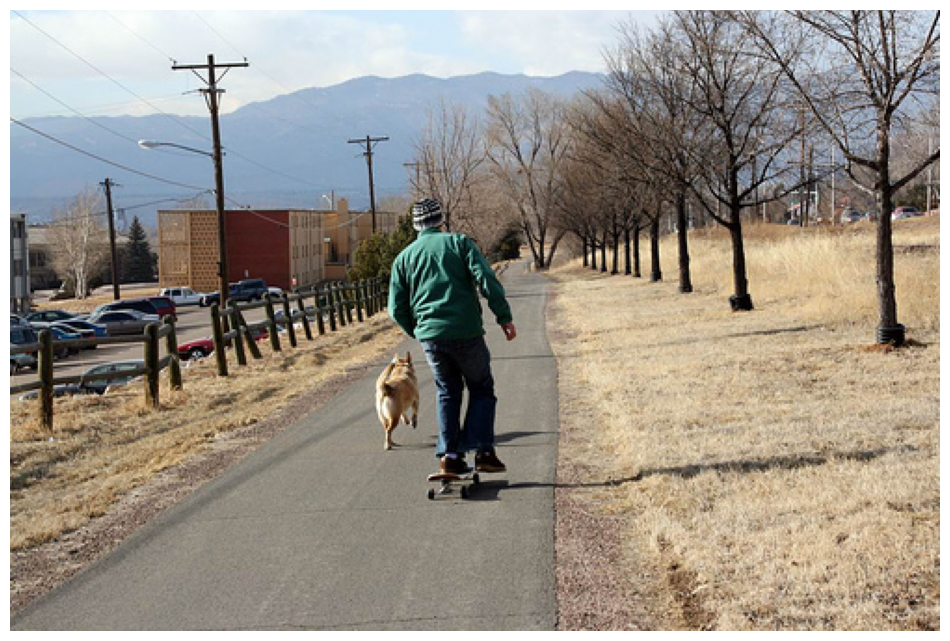

In [20]:
import cv2
import matplotlib.pyplot as plt
import pylab
%matplotlib inline

file_path = '/content/data/' + img['file_name']

image_array = cv2.imread(file_path)
image_array = cv2.cvtColor(image_array, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 14))
plt.axis('off')
plt.imshow(image_array)
plt.show()

### Instance Segmentation 시각화 - COCO API 활용한 시각화
* getAnnIds()로 특정 image에 해당하는 annotation id를 가져온 후에 이 id를 loadAnns()로 입력하여 해당 이미지의 모든 annotation 정보를 가져옴.
* segmentation 정보는 polygon 형태로 되어 있음.
* annotation 정보를 coco.showAnns(anns)에 입력하여 instance segmentation 시각화 수행.

In [21]:
annIds = coco.getAnnIds(imgIds=img['id'],catIds=catIds,iscrowd=None)
annIds
# 3개 정보 --> dog:18,skateboard:41, person:1

[10673, 638724, 2162813]

In [22]:
anns = coco.loadAnns(annIds)
anns

[{'segmentation': [[216.7,
    211.89,
    216.16,
    217.81,
    215.89,
    220.77,
    215.89,
    223.73,
    217.77,
    225.35,
    219.12,
    224.54,
    219.12,
    220.5,
    219.66,
    217.27,
    219.93,
    212.7,
    220.46,
    207.85,
    219.66,
    203.01,
    218.85,
    198.43,
    217.77,
    195.74,
    216.7,
    194.93,
    215.62,
    190.62,
    215.62,
    186.59,
    214.27,
    183.89,
    211.85,
    184.16,
    211.85,
    187.66,
    210.24,
    187.66,
    209.16,
    184.97,
    207.81,
    183.36,
    205.12,
    186.59,
    205.12,
    189.28,
    201.08,
    192.78,
    199.74,
    195.2,
    196.78,
    200.04,
    196.51,
    203.01,
    198.12,
    205.43,
    197.32,
    209.2,
    196.78,
    213.23,
    197.05,
    218.89,
    199.74,
    221.85,
    201.62,
    225.35,
    201.62,
    233.69,
    201.08,
    236.11,
    202.97,
    236.38,
    204.85,
    236.11,
    204.58,
    232.34,
    203.78,
    228.85,
    205.39,
    233.15,
    20

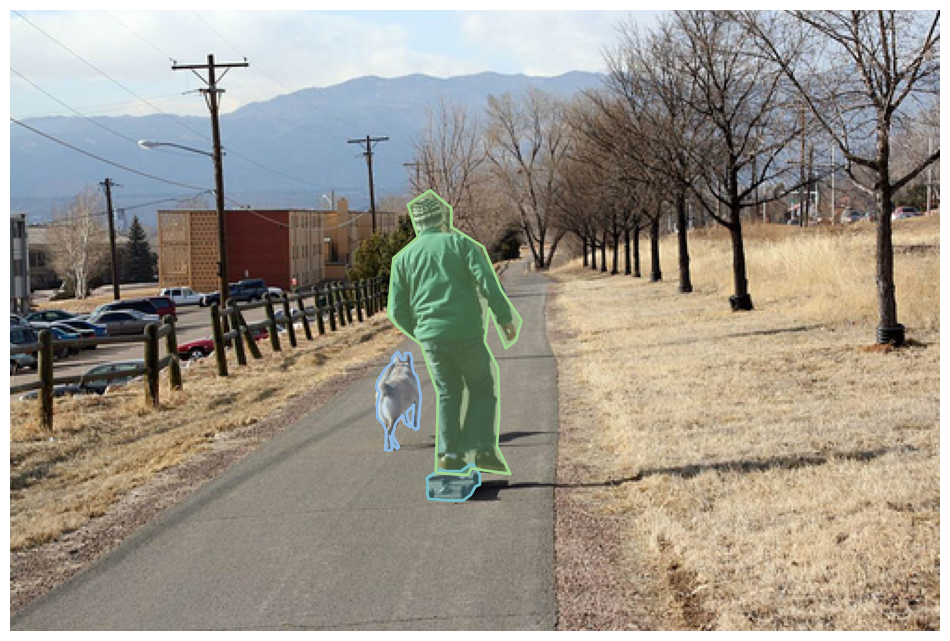

In [23]:
plt.figure(figsize=(12,14))
plt.imshow(image_array  )
plt.axis('off')

# showAnns( )는 annotation 정보들을 입력 받아서 Visualization 시켜줌. 단 먼저 matplotlib 객체로 원본 이미지가 먼저 로드되어 있어야 함.
coco.showAnns(anns)

### Polygon Annotation 정보를 이용하여 Instance Segmentation 시각화
* Polygon 정보를 직접 추출하여 이를 시각화
* polygon 정보를 coco API를 활용하여 masking 형태로 변환 후 해당 masking을 원본 이미지에 적용하여 시각화.

In [24]:
len(anns),type(anns[0])

(3, dict)

In [25]:
ann_2_seg = anns[2]['segmentation'][0]
print(type(ann_2_seg),len(ann_2_seg))
print(ann_2_seg)

<class 'list'> 52
[228.43, 247.9, 229.63, 206.62, 224.24, 191.07, 220.65, 179.7, 207.49, 169.53, 202.71, 163.55, 205.7, 133.04, 218.86, 121.68, 213.47, 104.33, 225.44, 96.55, 236.8, 106.12, 236.8, 116.29, 254.15, 127.06, 263.72, 150.39, 274.49, 166.54, 271.5, 177.31, 266.12, 181.5, 257.14, 159.96, 254.75, 177.91, 261.93, 192.27, 262.53, 216.79, 261.33, 234.14, 268.51, 249.1, 247.57, 246.11, 245.78, 249.69, 229.03, 248.5]


In [26]:
 # x,y 좌표값이 연이어 되어 있는 list형 polygon segmentation 정보를 x,y 쌍 형태로 변환.
 polygon_x = [x for index, x in enumerate(ann_2_seg) if index % 2 == 0]
 polygon_y = [x for index, x in enumerate(ann_2_seg) if index % 2 == 1]
 print('polygon_x:', polygon_x)
 print('polygon_y:', polygon_y)
 polygon_xy = [[x, y] for x, y in zip(polygon_x, polygon_y)]
 print('polygon_xy:', polygon_xy)

polygon_x: [228.43, 229.63, 224.24, 220.65, 207.49, 202.71, 205.7, 218.86, 213.47, 225.44, 236.8, 236.8, 254.15, 263.72, 274.49, 271.5, 266.12, 257.14, 254.75, 261.93, 262.53, 261.33, 268.51, 247.57, 245.78, 229.03]
polygon_y: [247.9, 206.62, 191.07, 179.7, 169.53, 163.55, 133.04, 121.68, 104.33, 96.55, 106.12, 116.29, 127.06, 150.39, 166.54, 177.31, 181.5, 159.96, 177.91, 192.27, 216.79, 234.14, 249.1, 246.11, 249.69, 248.5]
polygon_xy: [[228.43, 247.9], [229.63, 206.62], [224.24, 191.07], [220.65, 179.7], [207.49, 169.53], [202.71, 163.55], [205.7, 133.04], [218.86, 121.68], [213.47, 104.33], [225.44, 96.55], [236.8, 106.12], [236.8, 116.29], [254.15, 127.06], [263.72, 150.39], [274.49, 166.54], [271.5, 177.31], [266.12, 181.5], [257.14, 159.96], [254.75, 177.91], [261.93, 192.27], [262.53, 216.79], [261.33, 234.14], [268.51, 249.1], [247.57, 246.11], [245.78, 249.69], [229.03, 248.5]]


(np.float64(-0.5), np.float64(499.5), np.float64(333.5), np.float64(-0.5))

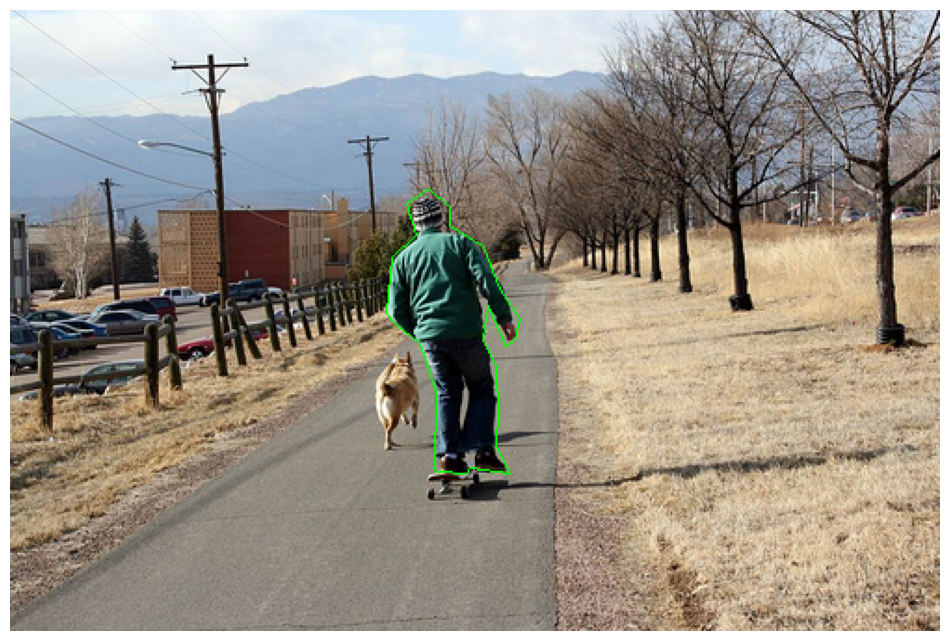

In [27]:
green_color = (0,255,0)

draw_img = image_array.copy()
polygon_xy = np.array(polygon_xy,np.int32)
draw_img = cv2.polylines(draw_img,[polygon_xy],True,green_color)

plt.figure(figsize=(12,14))
plt.imshow(draw_img)
plt.axis('off')

(np.float64(-0.5), np.float64(499.5), np.float64(333.5), np.float64(-0.5))

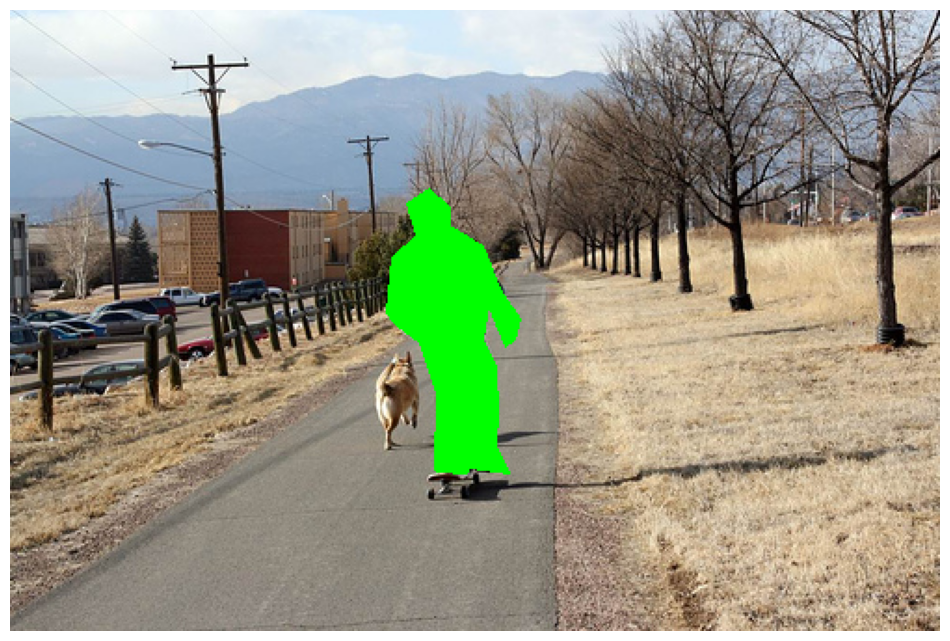

In [28]:
# opencv의 fillPoly를 이용하여 변환된 polygon 좌표 적용하여 instance segmentation 내부 시각화

draw_img = image_array.copy()
polygon_xy = np.array(polygon_xy,np.int32)
draw_img = cv2.fillPoly(draw_img,[polygon_xy],green_color)

plt.figure(figsize=(12,14))
plt.imshow(draw_img)
plt.axis('off')

In [29]:
# coco api의 annToMask()를 이용하여 polygon을 mask 형태로 변환
mask = coco.annToMask(anns[2])
print(image_array.shape,mask.shape)

print(mask[mask > 0].shape) # (6014,)
print(mask[mask == 0].shape) # (160986,)
mask[mask> 0]   # mask가 1인 부분인 Segmentaion 내부이고 외부는 모두 0으로 채워짐

(334, 500, 3) (334, 500)
(6014,)
(160986,)


array([1, 1, 1, ..., 1, 1, 1], dtype=uint8)

(np.float64(-0.5), np.float64(499.5), np.float64(333.5), np.float64(-0.5))

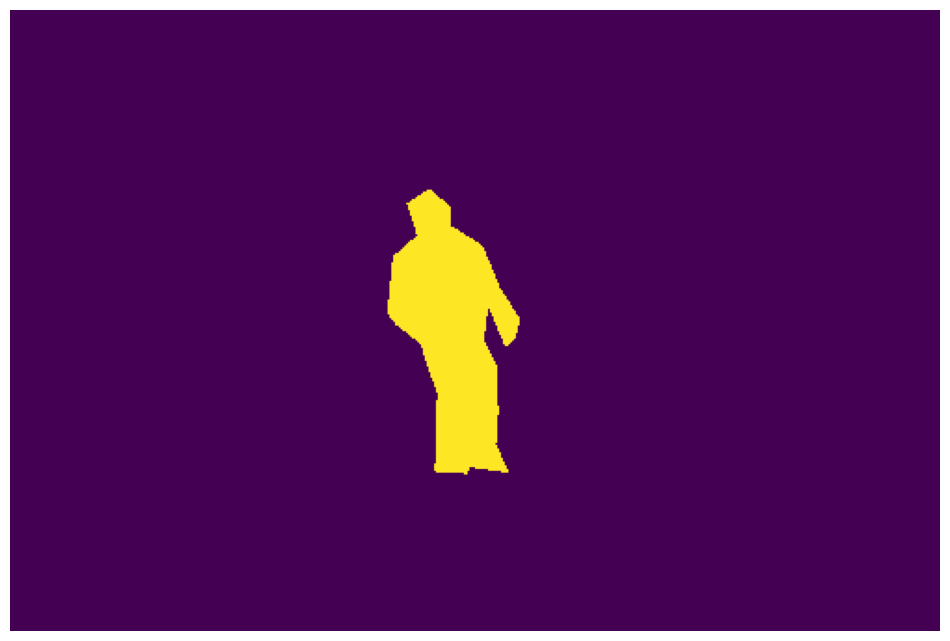

In [30]:
plt.figure(figsize=(12,14))
plt.imshow(mask)
plt.axis('off')

### Polygon 정보를 mask로 변환하여 Instance Segmentation 시각화
* cv2.fillPoly()로 polygon을 mask형태로 변환.
* layer별 masking 영역에서 0을 제외한 pixel 영역을 layer별 시각화

zero_mask shape: (334, 500) mask shape: (334, 500)
masked_polygon 0보다 큰 값: [1. 1. 1. ... 1. 1. 1.]
(6184,) (160816,)


(np.float64(-0.5), np.float64(499.5), np.float64(333.5), np.float64(-0.5))

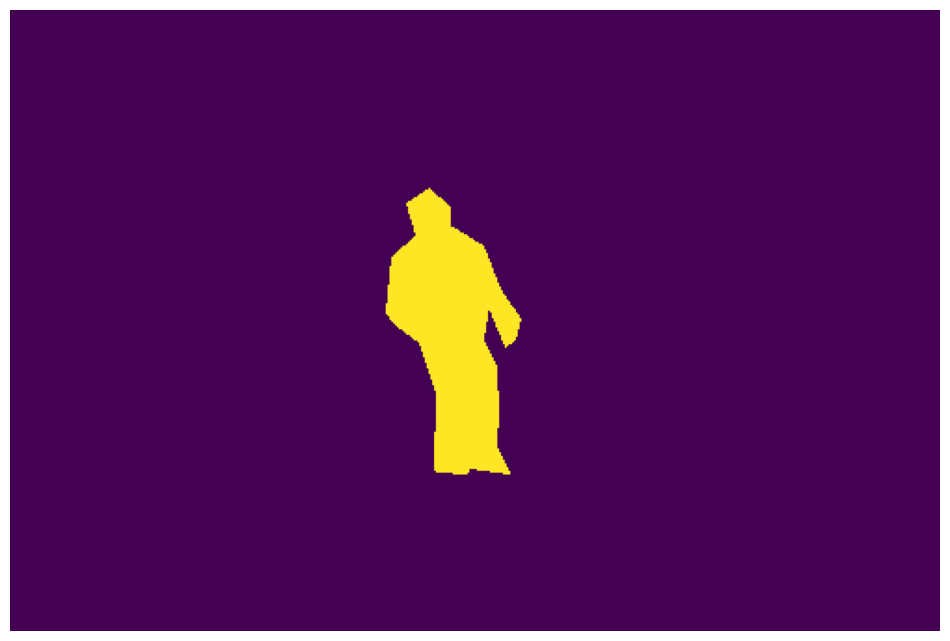

In [31]:
## polygon 정보를 mask 정보로 변환.
zero_mask = np.zeros(image_array.shape[0:2]) # mask 정보는 2차원 선호
masked_polygon = cv2.fillPoly(zero_mask, [polygon_xy], 1)  # color:1
print('zero_mask shape:', zero_mask.shape, 'mask shape:', masked_polygon.shape)
print('masked_polygon 0보다 큰 값:', masked_polygon[masked_polygon > 0])
print(masked_polygon[masked_polygon > 0].shape, masked_polygon[masked_polygon == 0].shape)

plt.figure(figsize=(12, 14))
plt.imshow(masked_polygon)
plt.axis('off')

In [32]:
# 보통 bool 값으로 masking 정보 제공.
masked_bool = masked_polygon.astype(bool)
print('masked_bool shape:', masked_bool.shape)
print(masked_bool[masked_bool==1].shape, masked_bool[masked_bool==0].shape)
print(masked_bool[masked_bool==1])

masked_bool shape: (334, 500)
(6184,) (160816,)
[ True  True  True ...  True  True  True]


In [33]:
# mask 값에 따라 channel 별로 alpha값을 감안하여 색상 적용
def apply_mask_01(image, mask, color, alpha=0.5):
    for c in range(3):
        image[:, :, c] = np.where(mask == 1,
                                image[:, :, c] *
                                (1 - alpha) + alpha * color[c] * 255,
                                image[:, :, c])
    return image

(np.float64(-0.5), np.float64(499.5), np.float64(333.5), np.float64(-0.5))

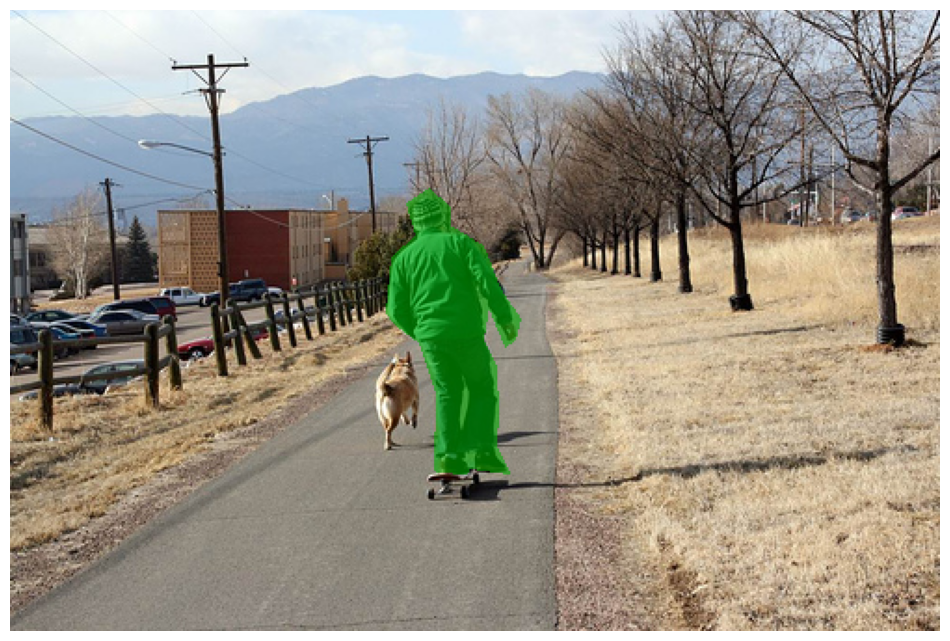

In [34]:
draw_img = image_array.copy()
# masking 정보는 2차원 bool array로 전달.
masked_image = apply_mask_01(draw_img, masked_bool, (0, 255, 0), alpha=0.6)

plt.figure(figsize=(12, 14))
plt.imshow(masked_image)
plt.axis('off')

### bitwise_and 연산으로 오브젝트 영역을 제외하고 나머지 영역은 모두 0 처리하기


(np.float64(-0.5), np.float64(499.5), np.float64(333.5), np.float64(-0.5))

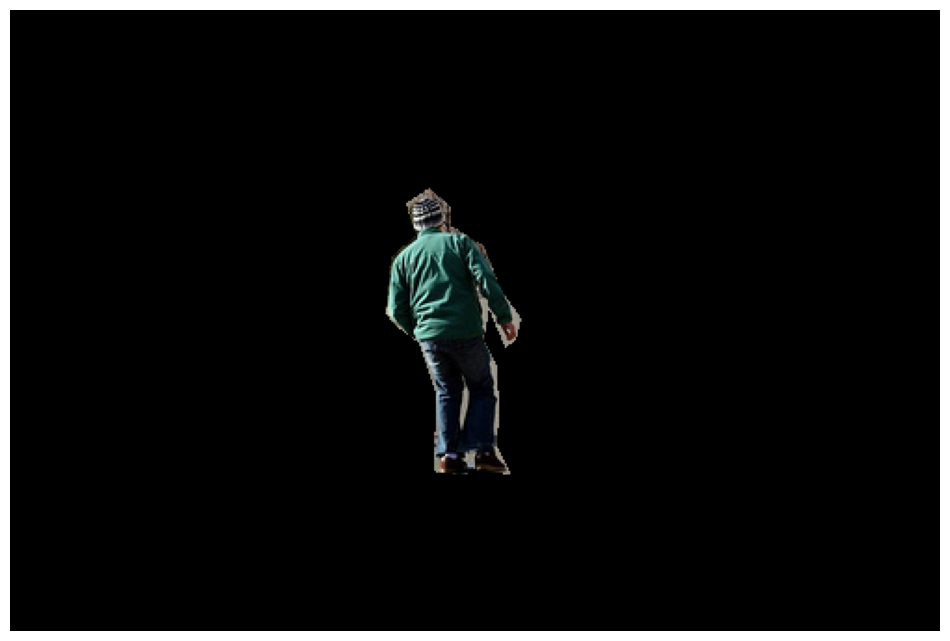

In [35]:
# True는 255로, False는 0으로 변환.
s_mask_int = (masked_bool * 255).astype("uint8")
draw_img = image_array.copy()
# opencv의 bitwise_and()로 masking 255 영역만 object로 나타내고, 0 영역은 검은색으로 시각화

# https://velog.io/@dldndyd01/OpenCV-bitwiseand-or-xor-not-%EA%B8%B0%EB%8A%A5-%EC%A0%95%EB%A6%AC-RGB-Image
only_mask_image = cv2.bitwise_and(draw_img, draw_img, mask=s_mask_int)
plt.figure(figsize=(12, 14))
plt.imshow(only_mask_image)
plt.axis('off')

loading annotations into memory...
Done (t=0.37s)
creating index...
index created!


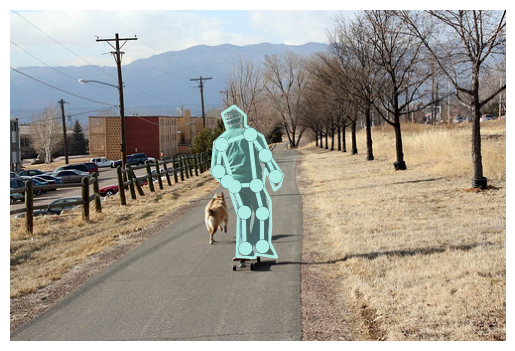

In [36]:
# load and display keypoints annotations
# https://eehoeskrap.tistory.com/540

annFile = '{}/annotations/person_keypoints_{}.json'.format(dataDir,dataType)
coco_kps = COCO(annFile)
plt.imshow(image_array); plt.axis('off')
ax = plt.gca()
annIds = coco_kps.getAnnIds(imgIds=img['id'], catIds=catIds, iscrowd=None)
anns = coco_kps.loadAnns(annIds)
coco_kps.showAnns(anns)